# Supplemental, find kappa for the chromatin

Code to compute the MG1 DG1 measure for finding the optimal kappa for the chromatin.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [56]:
from src.config import load_default_chrom_configs
from src.combined_chromatin_model import CombinedChromatinModel

config1, config2 = load_default_chrom_configs()

combined_model = CombinedChromatinModel(config1=config1, config2=config2)

chrom = 1
mnase_span = 45000, 47000

# Load window to deconvolve
combined_model.load_mnase_span(chrom, mnase_span)
combined_model.setup_deconv_model(copy_correct=False)


Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1999) to (16, 26, 200)
Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 1999) to (15, 26, 200)
Loading copy correction N, Fr, B from output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr


In [57]:
combined_model.deconvolve(gamma=0.07, kappa=0.01, eta=0)

0/5200 - 00:00:00.003
500/5200 - 00:00:00.364
1000/5200 - 00:00:27.868
1500/5200 - 00:01:43.085
2000/5200 - 00:03:04.766
2500/5200 - 00:04:27.044
3000/5200 - 00:05:53.140
3500/5200 - 00:07:26.840
4000/5200 - 00:09:04.061
4500/5200 - 00:10:36.658
5000/5200 - 00:12:02.293
Completed - 00:12:16.763


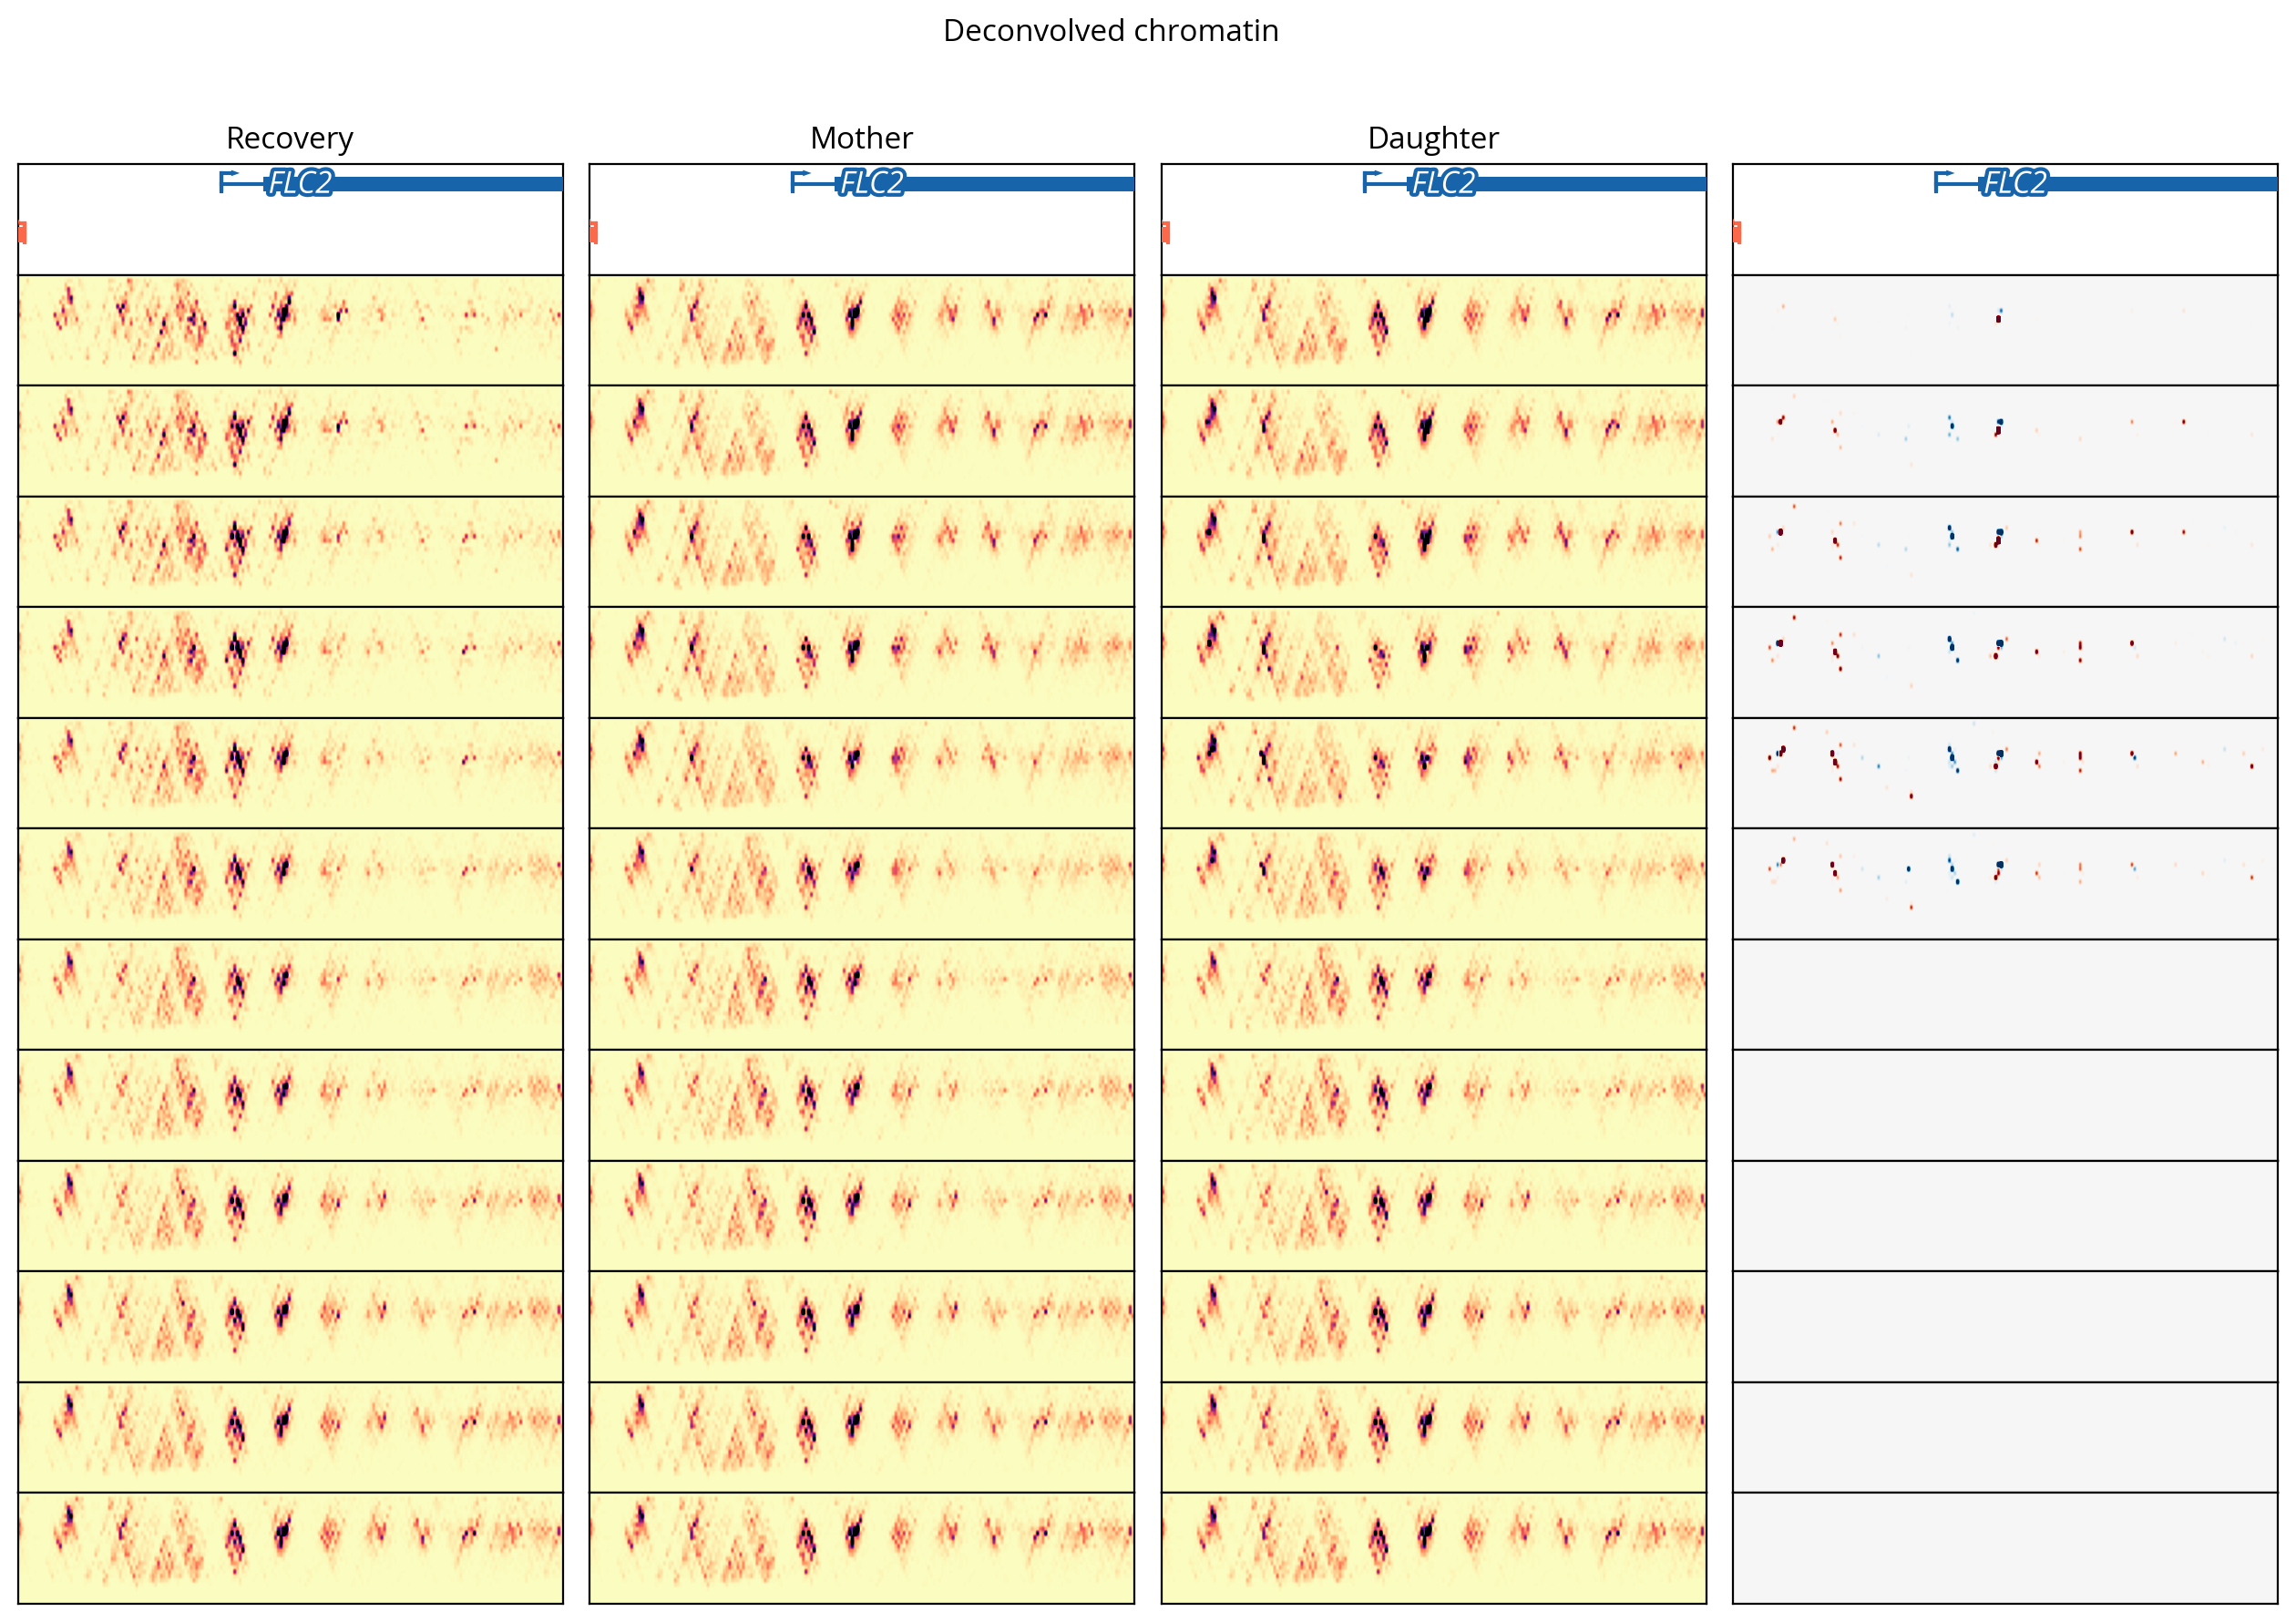

In [61]:
combined_model.plot_branches(figsize=(16, 10))

In [244]:
from src.dg1_mg1_island_analysis import ChromatinOccupancyIslandDetector

# Usage:
detector = ChromatinOccupancyIslandDetector(config1, config2, F)
detector.step1_preprocess_data(min_occupancy=1e-3)
_ = detector.step2_analyze_distribution(std_multiplier=1, plot=False)

F_imgs shape: (257, 26, 200)
MG1 shape: (64, 26, 200)
DG1 shape: (64, 26, 200)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 200), DG1: (26, 200)
Total positions: 5200
Filtered positions: 3576
Filtered percentage: 68.8%
=== Step 2: Distribution Analysis ===
Mean difference: 0.054
Std difference: 2.735
Threshold range: [-2.682, 2.789]


=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 205
Detected 15 total occupancy islands
Mother/Daughter pixels: 9
Remaining pixels after M/D subtraction: 196
Detected 15 unchanging islands


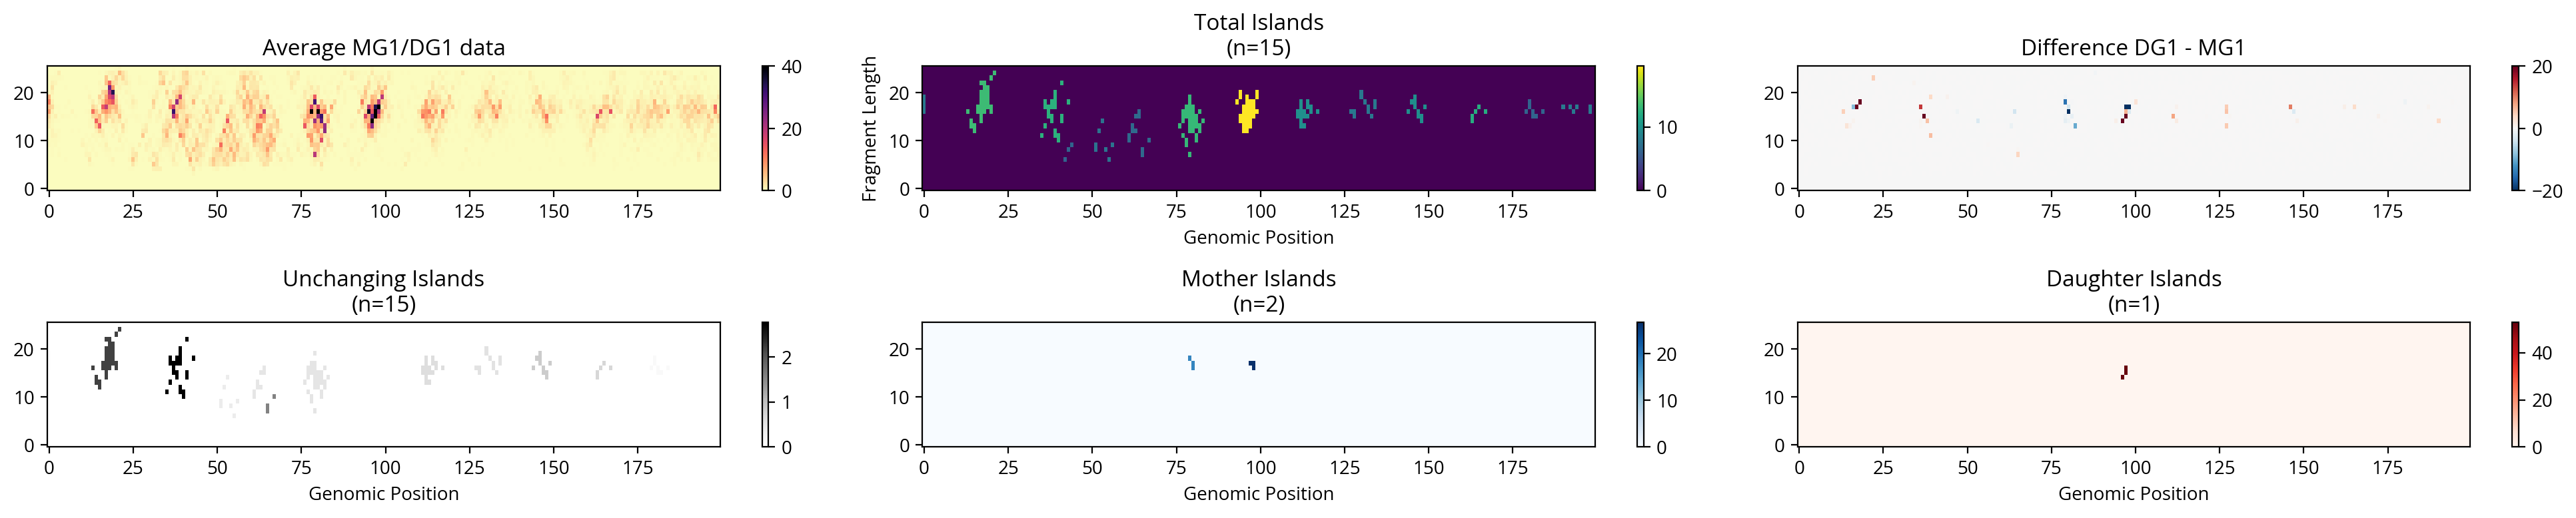

In [242]:
all_islands = detector.detect_all_island_types(max_distance=4, min_size=3,
    occupancy_threshold=5)
detector.plot_all_islands_overview()

In [243]:
_ = detector.comprehensive_summary()


CHROMATIN LANDSCAPE COMPOSITION ANALYSIS

🧬 CHROMATIN BREAKDOWN:
   Total chromatin regions detected: 15 islands
   Genome coverage by chromatin: 3.9%

📊 CHROMATIN COMPOSITION (by island count):
   • Mother-specific:    11.1% (2 islands)
   • Daughter-specific:  5.6% (1 islands)
   • Unchanging:         83.3% (15 islands)

📊 CHROMATIN COMPOSITION (by pixel coverage):
   • Mother-specific:    3.0%
   • Daughter-specific:  1.5%
   • Unchanging:         95.5%
